## Pruebas de los modelos listos obtenidos para que el agente los utilice. Parametrizable

In [ ]:
from pathlib import Path
import pickle
import sys
import tempfile

import numpy as np
import pandas as pd
import torch
import torch.nn as nn

# Parametriza aquí los datos del cliente (sin CustomerID ni Churn).
cliente = {
    "gender": "Male",
    "SeniorCitizen": 0,
    "Partner": "Yes",
    "Dependents": "No",
    "tenure": 12,
    "PhoneService": "Yes",
    "MultipleLines": "No",
    "InternetService": "DSL",
    "OnlineSecurity": "No",
    "OnlineBackup": "Yes",
    "DeviceProtection": "No",
    "TechSupport": "No",
    "StreamingTV": "No",
    "StreamingMovies": "No",
    "Contract": "Month-to-month",
    "PaperlessBilling": "Yes",
    "PaymentMethod": "Electronic check",
    "MonthlyCharges": 500.0,
    "TotalCharges": 600.0,
}

# Localiza el proyecto y carga los modelos guardados.
project_root = next(
    (
        parent
        for parent in (Path.cwd(), *Path.cwd().parents)
        if (parent / "src" / "w1_supervized_learning").is_dir()
    ),
    None,
)
if project_root is None:
    raise FileNotFoundError("No se encontró la carpeta src del proyecto.")

src_dir = project_root / "src"
sys.path.insert(0, str(src_dir))

checkpoint_dir = src_dir / "w1_supervized_learning" / "checkpoints"
with open(checkpoint_dir / "xgboost_telco.pkl", "rb") as f:
    xgb_artifact = pickle.load(f)
with open(checkpoint_dir / "neural_network_telco.pkl", "rb") as f:
    nn_artifact = pickle.load(f)

# Ajusta encoder y scaler igual que al entrenar. La división del preprocesador es fija.
from w1_supervized_learning.data_preprocessing.data_preprocessing_telco import (
    PreprocessingTelco,
)

with tempfile.TemporaryDirectory() as temp_dir:
    prep = PreprocessingTelco(split_output_path=Path(temp_dir) / "splits.npz")
    prep.preprocess()

# Reproduce el feature engineering y el orden de columnas del entrenamiento.
cliente_df = pd.DataFrame([cliente])
cliente_df["NewCustomer"] = (cliente_df["tenure"] == 0).astype(int)
cliente_df["AvgMonthlyCharges"] = np.where(
    cliente_df["tenure"] > 0,
    cliente_df["TotalCharges"] / cliente_df["tenure"],
    0,
)

categorical_features = prep.categorical_features
continuous_features = prep.continuous_features

encoded = prep.encoder.transform(cliente_df[categorical_features])
numeric = cliente_df.drop(columns=categorical_features).copy()
numeric[continuous_features] = numeric[continuous_features].astype(float)
numeric.loc[:, continuous_features] = prep.scaler.transform(
    numeric[continuous_features]
)

encoded_df = pd.DataFrame(
    encoded,
    columns=prep.encoder.get_feature_names_out(categorical_features),
    index=cliente_df.index,
)
X_cliente = pd.concat([numeric, encoded_df], axis=1)

# Evita predecir si el orden de características no coincide con el usado al guardar.
feature_names = list(xgb_artifact["feature_names"])
if feature_names != list(nn_artifact["feature_names"]):
    raise ValueError("Los modelos guardados tienen distinto orden de características.")
if feature_names != list(X_cliente.columns):
    raise ValueError("Las características de entrada no coinciden con las de los modelos.")

X_input = X_cliente.to_numpy(dtype=np.float32)

# Predicción de XGBoost.
xgb_probability = float(xgb_artifact["model"].predict_proba(X_input)[0, 1])
xgb_prediction = (
    "Churn" if xgb_probability >= xgb_artifact["threshold"] else "No churn"
)

# Reconstruye la arquitectura de la red y carga sus pesos.
class CheckpointMLP(nn.Module):
    def __init__(self, input_dim, hidden_dims, dropout_p=0.0, use_batchnorm=False):
        super().__init__()
        layers = []
        previous_dim = input_dim

        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(previous_dim, hidden_dim))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(hidden_dim))
            layers.append(nn.ReLU())
            if dropout_p > 0:
                layers.append(nn.Dropout(dropout_p))
            previous_dim = hidden_dim

        layers.append(nn.Linear(previous_dim, 1))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
nn_model = CheckpointMLP(**nn_artifact["model_config"]).to(device)
nn_model.load_state_dict(nn_artifact["state_dict"])
nn_model.eval()

with torch.inference_mode():
    logits = nn_model(torch.as_tensor(X_input, device=device)).squeeze(1)
    nn_probability = float(torch.sigmoid(logits).item())

nn_prediction = (
    "Churn" if nn_probability >= nn_artifact["threshold"] else "No churn"
)

print(f"XGBoost:       {xgb_prediction} (probabilidad de churn: {xgb_probability:.3f})")
print(f"Neural network: {nn_prediction} (probabilidad de churn: {nn_probability:.3f})")

XGBoost:       Churn (probabilidad de churn: 0.415)
Neural network: No churn (probabilidad de churn: 0.483)


# Pruebas de los modelos listos obtenidos para que el agente los utilice.

,real,probabilidad_XGBoost,predicción_XGBoost,probabilidad_Neural_Network,predicción_Neural_Network
Cliente 1,Churn,0.147,No churn,0.210,No churn
Cliente 2,Churn,0.481,Churn,0.368,No churn
Cliente 3,Churn,0.114,No churn,0.172,No churn
Cliente 4,Churn,0.599,Churn,0.668,Churn
Cliente 5,Churn,0.713,Churn,0.739,Churn
Cliente 6,Churn,0.852,Churn,0.819,Churn
Cliente 7,Churn,0.375,No churn,0.467,No churn
Cliente 8,Churn,0.405,Churn,0.411,No churn
Cliente 9,Churn,0.800,Churn,0.858,Churn
Cliente 10,Churn,0.780,Churn,0.867,Churn


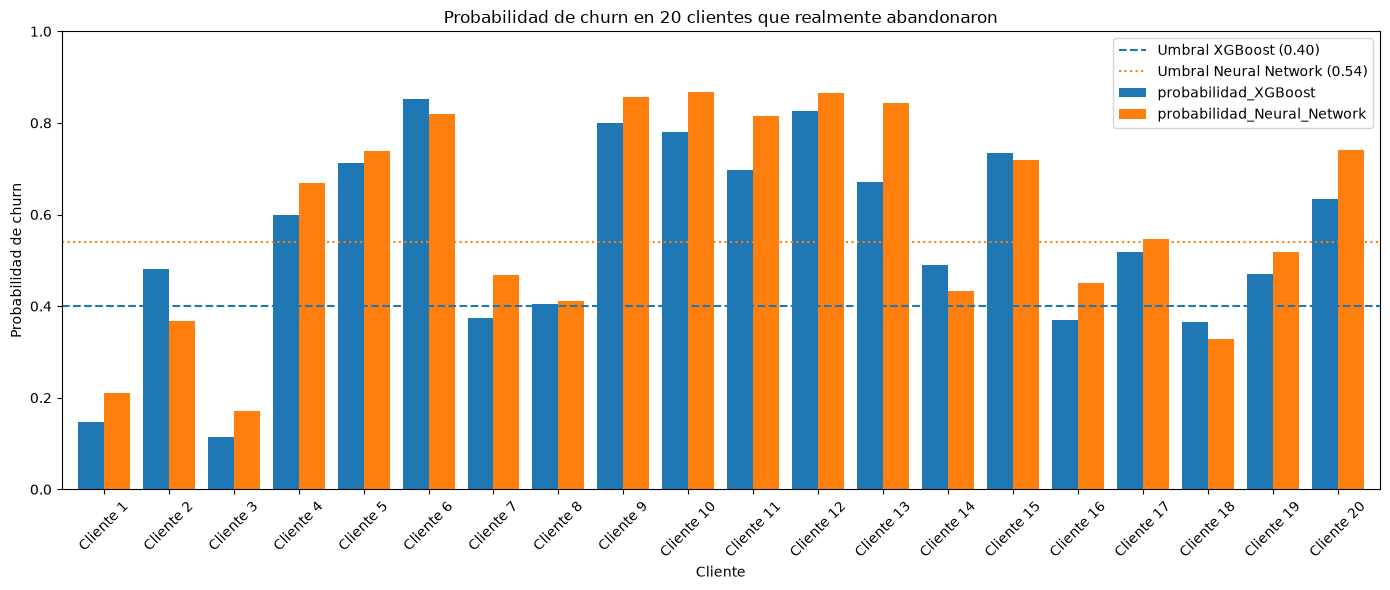

In [3]:
from pathlib import Path
import pickle
import sys
import tempfile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

# Busca los modelos guardados.
project_root = next(
    (
        parent
        for parent in (Path.cwd(), *Path.cwd().parents)
        if (parent / "src" / "w1_supervized_learning").is_dir()
    ),
    None,
)
if project_root is None:
    raise FileNotFoundError("No se encontró la carpeta src del proyecto.")

src_dir = project_root / "src"
sys.path.insert(0, str(src_dir))
checkpoint_dir = src_dir / "w1_supervized_learning" / "checkpoints"

with open(checkpoint_dir / "xgboost_telco.pkl", "rb") as f:
    xgb_artifact = pickle.load(f)
with open(checkpoint_dir / "neural_network_telco.pkl", "rb") as f:
    nn_artifact = pickle.load(f)

# Ajusta encoder y scaler con el mismo preprocesador usado durante el entrenamiento.
from w1_supervized_learning.data_preprocessing.data_preprocessing_telco import (
    PreprocessingTelco,
)

with tempfile.TemporaryDirectory() as temp_dir:
    prep = PreprocessingTelco(split_output_path=Path(temp_dir) / "splits.npz")
    prep.preprocess()

# Toma 20 clientes reales que sí abandonaron.
churn_clients = prep.telco_churn_df.loc[
    prep.telco_churn_df["Churn"].eq(1)
].sample(n=20, random_state=42)

X_raw = churn_clients.drop(columns="Churn").copy()
X_raw["NewCustomer"] = (X_raw["tenure"] == 0).astype(int)
X_raw["AvgMonthlyCharges"] = np.where(
    X_raw["tenure"] > 0,
    X_raw["TotalCharges"] / X_raw["tenure"],
    0,
)

categorical_features = prep.categorical_features
continuous_features = prep.continuous_features

encoded = prep.encoder.transform(X_raw[categorical_features])
numeric = X_raw.drop(columns=categorical_features).copy()
numeric[continuous_features] = numeric[continuous_features].astype(float)
numeric.loc[:, continuous_features] = prep.scaler.transform(
    numeric[continuous_features]
)

encoded_df = pd.DataFrame(
    encoded,
    columns=prep.encoder.get_feature_names_out(categorical_features),
    index=X_raw.index,
)
X_clients = pd.concat([numeric, encoded_df], axis=1)

feature_names = list(xgb_artifact["feature_names"])
if feature_names != list(nn_artifact["feature_names"]):
    raise ValueError("Los modelos no tienen el mismo orden de características.")
if feature_names != list(X_clients.columns):
    raise ValueError("Las características no coinciden con las de los modelos.")

X_input = X_clients[feature_names].to_numpy(dtype=np.float32)

# Probabilidades y clases predichas por XGBoost.
xgb_probabilities = xgb_artifact["model"].predict_proba(X_input)[:, 1]
xgb_predictions = xgb_probabilities >= xgb_artifact["threshold"]

# Reconstruye la red neuronal y carga sus pesos.
class CheckpointMLP(nn.Module):
    def __init__(self, input_dim, hidden_dims, dropout_p=0.0, use_batchnorm=False):
        super().__init__()
        layers = []
        previous_dim = input_dim

        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(previous_dim, hidden_dim))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(hidden_dim))
            layers.append(nn.ReLU())
            if dropout_p > 0:
                layers.append(nn.Dropout(dropout_p))
            previous_dim = hidden_dim

        layers.append(nn.Linear(previous_dim, 1))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
nn_model = CheckpointMLP(**nn_artifact["model_config"]).to(device)
nn_model.load_state_dict(nn_artifact["state_dict"])
nn_model.eval()

with torch.inference_mode():
    logits = nn_model(torch.as_tensor(X_input, device=device)).squeeze(1)
    nn_probabilities = torch.sigmoid(logits).cpu().numpy()

nn_predictions = nn_probabilities >= nn_artifact["threshold"]

# Tabla de comparación: todos estos clientes realmente abandonaron.
comparison = pd.DataFrame(
    {
        "real": "Churn",
        "probabilidad_XGBoost": xgb_probabilities,
        "predicción_XGBoost": np.where(xgb_predictions, "Churn", "No churn"),
        "probabilidad_Neural_Network": nn_probabilities,
        "predicción_Neural_Network": np.where(nn_predictions, "Churn", "No churn"),
    },
    index=[f"Cliente {i + 1}" for i in range(len(churn_clients))],
)
display(comparison.round(3))

# Gráfica de probabilidades estimadas para cada cliente.
ax = comparison[
    ["probabilidad_XGBoost", "probabilidad_Neural_Network"]
].plot(kind="bar", figsize=(14, 6), width=0.8)

ax.axhline(
    xgb_artifact["threshold"],
    color="C0",
    linestyle="--",
    label=f"Umbral XGBoost ({xgb_artifact['threshold']:.2f})",
)
ax.axhline(
    nn_artifact["threshold"],
    color="C1",
    linestyle=":",
    label=f"Umbral Neural Network ({nn_artifact['threshold']:.2f})",
)
ax.set(
    title="Probabilidad de churn en 20 clientes que realmente abandonaron",
    xlabel="Cliente",
    ylabel="Probabilidad de churn",
    ylim=(0, 1),
)
ax.tick_params(axis="x", rotation=45)
ax.legend()
plt.tight_layout()
plt.show()